
🔥 XGBoost Accuracy with Priority Feature: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Confusion Matrix:
[[200   0]
 [  0 200]]


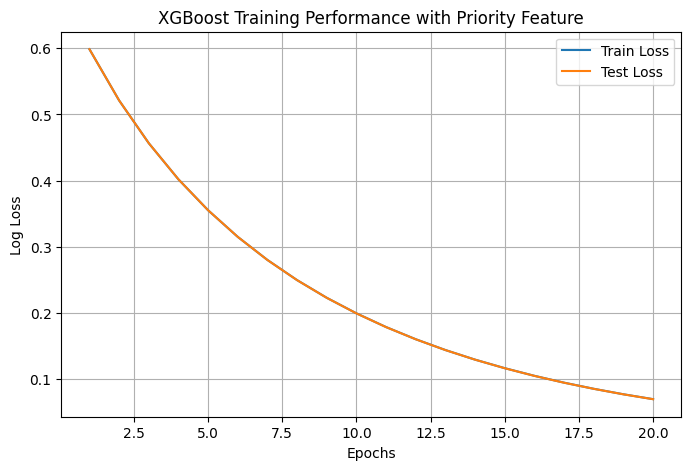


💾 Model saved as xgboost_asthma_priority_20epochs.pkl


In [1]:
# =====================================================
# XGBOOST TRAINING WITH PRIORITY LEVEL FEATURE
# 20 EPOCHS + ACCURACY GRAPH + MODEL SAVE
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# -------------------------------
# LOAD CORRECT DATASET
# -------------------------------
path = r"C:/Users/ADMIN/Desktop/student file/student file/train/asthma_dataset_corrected.csv"
df = pd.read_csv(path)

# -------------------------------
# ENCODE CATEGORICAL FEATURES
# -------------------------------
for col in ['gender', 'smoking']:
    df[col] = LabelEncoder().fit_transform(df[col])

# -------------------------------
# CREATE PRIORITY LEVEL FEATURE
# 0 = Low, 1 = Medium, 2 = High
# -------------------------------
def assign_priority(row):
    if row['FEV1'] < 2.0 and row['PEFR'] < 300 and row['PM2_5'] > 60:
        return 2   # High priority
    elif row['PM2_5'] > 40 or row['dust'] > 40 or row['FEV1'] < 2.5:
        return 1   # Medium priority
    else:
        return 0   # Low priority

df['priority_level'] = df.apply(assign_priority, axis=1)

# -------------------------------
# ENCODE TARGET LABEL
# -------------------------------
df['asthma_stage'] = df['asthma_stage'].map({'Normal': 0, 'Asthma': 1})

# -------------------------------
# FEATURE SELECTION (UPDATED)
# -------------------------------
X = df[['age','PM2_5','dust','FEV1','FVC','PEFR','gender','smoking','priority_level']]
y = df['asthma_stage']

# -------------------------------
# TRAIN–TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# FEATURE SCALING
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# XGBOOST MODEL (20 EPOCHS)
# -------------------------------
xgb_model = XGBClassifier(
    n_estimators=20,          # 🔥 20 epochs
    learning_rate=0.1,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# -------------------------------
# TRAIN MODEL WITH EVAL SET
# -------------------------------
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# -------------------------------
# FINAL EVALUATION
# -------------------------------
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🔥 XGBoost Accuracy with Priority Feature: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------------
# ACCURACY / LOSS GRAPH
# -------------------------------
results = xgb_model.evals_result()

train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), train_loss, label="Train Loss")
plt.plot(range(1, 21), test_loss, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("XGBoost Training Performance with Priority Feature")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# SAVE MODEL & SCALER
# -------------------------------
joblib.dump(xgb_model, "xgboost_asthma_priority_20epochs.pkl")
joblib.dump(scaler, "xgboost_priority_scaler.pkl")

print("\n💾 Model saved as xgboost_asthma_priority_20epochs.pkl")
